In [1]:
%pip install --upgrade graphvision-ai==0.2.4

  Attempting uninstall: graphvision-ai
    Found existing installation: graphvision-ai 0.2.3
    Uninstalling graphvision-ai-0.2.3:
      Successfully uninstalled graphvision-ai-0.2.3

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: /Users/aryangahlot/.pyenv/versions/tfenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from graphvision import GraphExtractor

# Initializes the class and downloads weights from Hugging Face once
extractor = GraphExtractor() 

# Fast extractions since the models are already loaded in memory
json_data1 = extractor.extract("./../Test/PieChart.png")
# json_data2 = extractor.extract("./../FigureQA_Dataset/no_annot_test2/png/1.png")

print(json_data1)

/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🧠 Booting up GraphVision AI Models from Hugging Face...

🚀 Analyzing: ./../Test/PieChart.png
----------------------------------------
📊 Detected Chart Type: PIE
{
    "chart_type": "pie",
    "title": "Tha Learning App",
    "data": {
        "Mathematics": 30.34,
        "Science": 23.11,
        "Social science": 16.99,
        "English": 22.5,
        "Hindi": 7.07
    }
}


In [3]:
!pip install transformers torch pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 25.5 MB/s eta 0:00:001m20.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.2.0
    Uninstalling hf-xet-1.2.0:
      Successfully uninstalled hf-xet-1.2.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.1.7
    Uninstalling huggingface_hub-1.1.7:
      Successfully uninstalled huggingface_hub-1.1.7

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import time
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import Pix2StructProcessor, Pix2StructForConditionalGeneration

from graphvision import GraphExtractor

In [3]:
# DePlot
processor = Pix2StructProcessor.from_pretrained("google/deplot")
model = Pix2StructForConditionalGeneration.from_pretrained("google/deplot")

device = "mps" if torch.cuda.is_available() else "cpu"
model.to(device)

# GraphVision
extractor = GraphExtractor()

The image processor of type `Pix2StructImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|███████████████████████████████████████████████████| 285/285 [00:00<00:00, 1831.83it/s, Materializing param=encoder.layernorm.weight]


🧠 Booting up GraphVision AI Models from Hugging Face...


In [4]:
def run_deplot(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        text="Generate underlying data table of the figure below:",
        return_tensors="pt"
    ).to(device)

    start = time.time()

    predictions = model.generate(**inputs, max_new_tokens=512)

    end = time.time()

    output = processor.decode(predictions[0], skip_special_tokens=True)

    print("\nDePlot Output:\n")
    print(output)

    print("\nTime:", end - start, "seconds")

In [5]:
def run_graphvision(image_path):

    start = time.time()

    result = extractor.extract(image_path)

    end = time.time()

    print("\nGraphVision Output:\n")
    print(result)

    print("\nTime:", end - start, "seconds")

In [6]:
def run_graphvision(image_path):

    start = time.time()

    result = extractor.extract(image_path)

    end = time.time()

    return result, end - start

In [7]:
def run_deplot(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        text="Generate underlying data table of the figure below:",
        return_tensors="pt"
    ).to(device)

    start = time.time()

    predictions = model.generate(**inputs, max_new_tokens=512)

    end = time.time()

    output = processor.decode(predictions[0], skip_special_tokens=True)

    return output, end - start

In [8]:
from graphvision import GraphExtractor

# Initializes the class and downloads weights from Hugging Face once
def run_graphvision(image_path):
    extractor = GraphExtractor() 

    start = time.time()
    # Fast extractions since the models are already loaded in memory
    json_data1 = extractor.extract(image_path)
    # json_data2 = extractor.extract("./../FigureQA_Dataset/no_annot_test2/png/1.png")
    
    end = time.time()

    return json_data1, end - start

In [9]:
def compare_models(image_path):

    # Show Image
    img = Image.open(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Graph")
    plt.show()

    # Run GraphVision
    gv_output, gv_time = run_graphvision(image_path)

    # Run DePlot
    deplot_output, deplot_time = run_deplot(image_path)

    print("\n=========== GraphVision-AI ===========\n")
    print(gv_output)
    print("\nTime:", gv_time, "seconds")

    print("\n=========== DePlot ===========\n")
    print(deplot_output)
    print("\nTime:", deplot_time, "seconds")

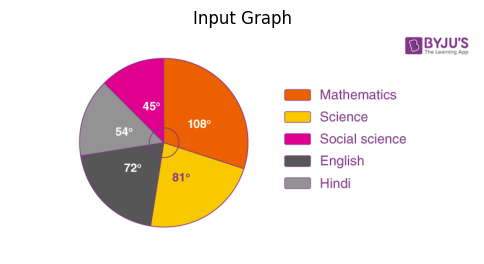

🧠 Booting up GraphVision AI Models from Hugging Face...

🚀 Analyzing: ./../Test/PieChart.png
----------------------------------------
📊 Detected Chart Type: PIE

=========== GraphVision-AI ===========

{
    "chart_type": "pie",
    "title": "Tha Learning App",
    "data": {
        "Mathematics": 30.34,
        "Science": 23.11,
        "Social science": 16.99,
        "English": 22.5,
        "Hindi": 7.07
    }
}

Time: 0.6006572246551514 seconds

=========== DePlot ===========

TITLE |  <0x0A> Mathematics | Mathematics | Science | Social science | English | Hindi <0x0A> BVJU's | 46% | 46% | 46% | 54% | 54% <0x0A> Mathematics | 72% | 81% | 79% | 54% | 54%

Time: 10.269865274429321 seconds


In [10]:
compare_models("./../Test/PieChart.png")

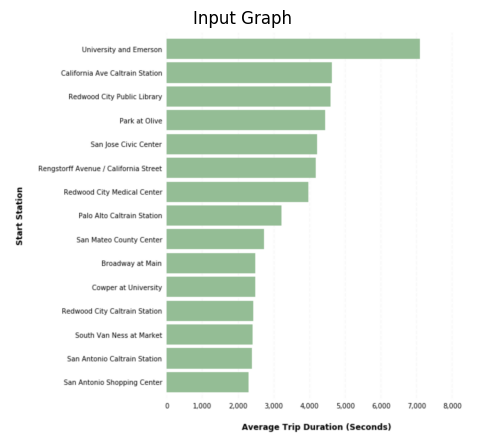

🧠 Booting up GraphVision AI Models from Hugging Face...

🚀 Analyzing: ./../Test/hbar2.png
----------------------------------------
📊 Detected Chart Type: HBAR_CATEGORICAL

=========== GraphVision-AI ===========

{
    "chart_type": "hbar_categorical",
    "title": null,
    "x_axis_label": "Average Trip Duration (Seconds)",
    "y_axis_label": "Start Station",
    "data": [
        {
            "category": "University and Emerson",
            "value": 7088.45
        },
        {
            "category": "Califomia Ave Caltrain Station",
            "value": 4628.76
        },
        {
            "category": "Redwood City Public Library",
            "value": 4590.23
        },
        {
            "category": "Park at Olive",
            "value": 4432.11
        },
        {
            "category": "San Jose Civic Center",
            "value": 4209.7
        },
        {
            "category": "Rengstorff Avenue / California Street",
            "value": 4173.64
        },
      

In [11]:
compare_models("./../Test/hbar2.png")

In [12]:
run_deplot("./../Test/hbar2.png")

('TITLE |  <0x0A> Start Station | Average Trip Duration (Seconds) <0x0A> San Antonio Shopping Center | 2301 <0x0A> San Antonio Caltrain Station | 2307 <0x0A> South Van Ness at Market | 2310 <0x0A> Redwood City Caltrain Station | 2311 <0x0A> Cowper at University | 2312 <0x0A> Broadway at Main | 2315 <0x0A> Palo Alto Caltrain Station | 3075 <0x0A> Redwood City Medical Center | 3951 <0x0A> San Jose Civic Center | 4304 <0x0A> California Ave Caltrain Station | 4613 <0x0A> University and Emerson | 7105',
 15.70194411277771)

In [13]:
run_graphvision("./../Test/hbar2.png")

🧠 Booting up GraphVision AI Models from Hugging Face...

🚀 Analyzing: ./../Test/hbar2.png
----------------------------------------
📊 Detected Chart Type: HBAR_CATEGORICAL


('{\n    "chart_type": "hbar_categorical",\n    "title": null,\n    "x_axis_label": "Average Trip Duration (Seconds)",\n    "y_axis_label": "Start Station",\n    "data": [\n        {\n            "category": "University and Emerson",\n            "value": 7088.45\n        },\n        {\n            "category": "Califomia Ave Caltrain Station",\n            "value": 4628.76\n        },\n        {\n            "category": "Redwood City Public Library",\n            "value": 4590.23\n        },\n        {\n            "category": "Park at Olive",\n            "value": 4432.11\n        },\n        {\n            "category": "San Jose Civic Center",\n            "value": 4209.7\n        },\n        {\n            "category": "Rengstorff Avenue / California Street",\n            "value": 4173.64\n        },\n        {\n            "category": "Redwood City Medical Center",\n            "value": 3969.51\n        },\n        {\n            "category": "Palo Alto Caltrain Station",\n           

## Real testing

In [14]:
import time
import torch
import matplotlib.pyplot as plt
from PIL import Image

from transformers import (
    Pix2StructProcessor,
    Pix2StructForConditionalGeneration,
    DonutProcessor,
    VisionEncoderDecoderModel
)

from graphvision import GraphExtractor

In [15]:
device = "mps" if torch.cuda.is_available() else "cpu"

# Pix2Struct
pix_processor = Pix2StructProcessor.from_pretrained("google/pix2struct-base")
pix_model = Pix2StructForConditionalGeneration.from_pretrained("google/pix2struct-base").to(device)

# DePlot (Pix2Struct fine-tuned)
deplot_processor = Pix2StructProcessor.from_pretrained("google/deplot")
deplot_model = Pix2StructForConditionalGeneration.from_pretrained("google/deplot").to(device)

# Donut
donut_processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
donut_model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base").to(device)

# GraphVision
extractor = GraphExtractor()

Loading weights: 100%|███████████████████████████████████████████████████| 285/285 [00:00<00:00, 2196.68it/s, Materializing param=encoder.layernorm.weight]
The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████████████████| 484/484 [00:00<00:00, 1736.99it/s, Materializing param=encoder.encoder.layers.3.blocks.1.output.dense.weight]
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🧠 Booting up GraphVision AI Models from Hugging Face...


In [16]:
def run_graphvision(image_path):

    start = time.time()
    result = extractor.extract(image_path)
    end = time.time()

    return result, end - start

In [17]:
def run_deplot(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = deplot_processor(
        images=image,
        text="Generate underlying data table of the figure below:",
        return_tensors="pt"
    ).to(device)

    start = time.time()

    predictions = deplot_model.generate(**inputs, max_new_tokens=512)

    end = time.time()

    output = deplot_processor.decode(predictions[0], skip_special_tokens=True)

    return output, end - start

In [18]:
def run_pix2struct(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = pix_processor(
        images=image,
        text="Describe the chart",
        return_tensors="pt"
    ).to(device)

    start = time.time()

    predictions = pix_model.generate(**inputs, max_new_tokens=512)

    end = time.time()

    output = pix_processor.decode(predictions[0], skip_special_tokens=True)

    return output, end - start

In [19]:
def run_donut(image_path):

    image = Image.open(image_path).convert("RGB")

    pixel_values = donut_processor(image, return_tensors="pt").pixel_values.to(device)

    start = time.time()

    outputs = donut_model.generate(pixel_values)

    end = time.time()

    result = donut_processor.batch_decode(outputs, skip_special_tokens=True)[0]

    return result, end - start

In [20]:
def compare_models(image_path):

    img = Image.open(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Graph")
    plt.show()

    # GraphVision
    gv_output, gv_time = run_graphvision(image_path)

    # DePlot
    deplot_output, deplot_time = run_deplot(image_path)

    # Pix2Struct
    pix_output, pix_time = run_pix2struct(image_path)

    # Donut
    donut_output, donut_time = run_donut(image_path)

    print("\n=========== GraphVision ===========")
    print(gv_output)
    print("Time:", gv_time)

    print("\n=========== DePlot ===========")
    print(deplot_output)
    print("Time:", deplot_time)

    print("\n=========== Pix2Struct ===========")
    print(pix_output)
    print("Time:", pix_time)

    print("\n=========== Donut ===========")
    print(donut_output)
    print("Time:", donut_time)

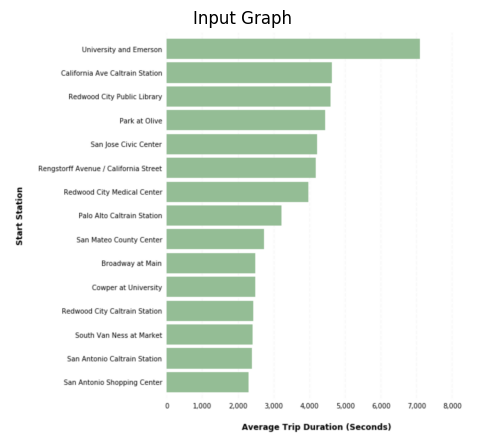


🚀 Analyzing: ./../Test/hbar2.png
----------------------------------------
📊 Detected Chart Type: HBAR_CATEGORICAL

=========== GraphVision ===========
{
    "chart_type": "hbar_categorical",
    "title": null,
    "x_axis_label": "Average Trip Duration (Seconds)",
    "y_axis_label": "Start Station",
    "data": [
        {
            "category": "University and Emerson",
            "value": 7088.45
        },
        {
            "category": "Califomia Ave Caltrain Station",
            "value": 4628.76
        },
        {
            "category": "Redwood City Public Library",
            "value": 4590.23
        },
        {
            "category": "Park at Olive",
            "value": 4432.11
        },
        {
            "category": "San Jose Civic Center",
            "value": 4209.7
        },
        {
            "category": "Rengstorff Avenue / California Street",
            "value": 4173.64
        },
        {
            "category": "Redwood City Medical Center",
 

In [21]:
compare_models("./../Test/hbar2.png")

In [23]:
result, time_taken = run_graphvision('./../FigureQA_Dataset/validation1/png/7.png')

print(result)
print(time_taken)


🚀 Analyzing: ./../FigureQA_Dataset/validation1/png/7.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL
{
    "chart_type": "vbar_categorical",
    "title": "title",
    "x_axis_label": "Xaxis label",
    "y_axis_label": "yaxis_label",
    "data": [
        {
            "category": "Medium Aqua",
            "value": 56.93
        },
        {
            "category": "Dark Gold",
            "value": 89.2
        },
        {
            "category": "Light Gold",
            "value": 43.57
        },
        {
            "category": "Mcdium Scafoam",
            "value": 88.23
        },
        {
            "category": "Midnight Bluc",
            "value": 47.35
        },
        {
            "category": "Grccn Yellow",
            "value": 59.4
        },
        {
            "category": "Aqua",
            "value": 83.11
        }
    ]
}
1.1920249462127686


In [24]:
result, time_taken = run_graphvision("./../Test/hbar2.png")

print(result)
print(time_taken)


🚀 Analyzing: ./../Test/hbar2.png
----------------------------------------
📊 Detected Chart Type: HBAR_CATEGORICAL
{
    "chart_type": "hbar_categorical",
    "title": null,
    "x_axis_label": "Average Trip Duration (Seconds)",
    "y_axis_label": "Start Station",
    "data": [
        {
            "category": "University and Emerson",
            "value": 7088.45
        },
        {
            "category": "Califomia Ave Caltrain Station",
            "value": 4628.76
        },
        {
            "category": "Redwood City Public Library",
            "value": 4590.23
        },
        {
            "category": "Park at Olive",
            "value": 4432.11
        },
        {
            "category": "San Jose Civic Center",
            "value": 4209.7
        },
        {
            "category": "Rengstorff Avenue / California Street",
            "value": 4173.64
        },
        {
            "category": "Redwood City Medical Center",
            "value": 3969.51
        }

In [30]:
result, time_taken = run_graphvision("./../FigureQA_Dataset/train1/png/99358.png")

print(result)
print(time_taken)


🚀 Analyzing: ./../FigureQA_Dataset/train1/png/99358.png
----------------------------------------
📊 Detected Chart Type: DOT_LINE
{
    "chart_type": "dot_line",
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "xaxis label",
    "total_points": 35,
    "data": [
        {
            "class": "Deep Pink",
            "x": -0.25,
            "y": 90.15
        },
        {
            "class": "Web Green",
            "x": -0.25,
            "y": 88.48
        },
        {
            "class": "Dark Cyan",
            "x": -0.25,
            "y": 88.0
        },
        {
            "class": "Dark Cyan",
            "x": -0.25,
            "y": 88.15
        },
        {
            "class": "Navy",
            "x": 14.04,
            "y": 88.0
        },
        {
            "class": "Dark Seafoam",
            "x": 14.04,
            "y": 88.94
        },
        {
            "class": "Dark Cyan",
            "x": 14.04,
            "y": 88.63
        }

In [6]:
result, time_taken = run_graphvision("./../FigureQA_Dataset/train1/png/99357.png")

print(result)
print(time_taken)


🚀 Analyzing: ./../FigureQA_Dataset/train1/png/99357.png
----------------------------------------
📊 Detected Chart Type: DOT_LINE
{
    "chart_type": "dot_line",
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "xaxis label",
    "total_points": 43,
    "data": [
        {
            "class": "Dark Periwinkle",
            "x": -0.04,
            "y": 8.84
        },
        {
            "class": "Web Green",
            "x": -0.04,
            "y": 9.89
        },
        {
            "class": "Hot Pink",
            "x": -0.04,
            "y": 69.89
        },
        {
            "class": "Cadet Blue",
            "x": -0.04,
            "y": 14.32
        },
        {
            "class": "Hot Pink",
            "x": 14.11,
            "y": 68.84
        },
        {
            "class": "Salmon",
            "x": 14.11,
            "y": 65.05
        },
        {
            "class": "Dark Periwinkle",
            "x": 14.11,
            "y": 16.42

In [25]:
result, time_taken = run_graphvision("./../FigureQA_Dataset/sample_train1/png/720.png")

print(result)
print(time_taken)


🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/720.png
----------------------------------------
📊 Detected Chart Type: PIE
{
    "chart_type": "pie",
    "title": "title",
    "data": {
        "Gold": 39.02,
        "Dark Red": 48.37,
        "Dark Orange": 12.61
    }
}
0.41989612579345703


In [26]:
result, time_taken = run_graphvision("./../FigureQA_Dataset/sample_train1/png/721.png")

print(result)
print(time_taken)


🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/721.png
----------------------------------------
📊 Detected Chart Type: PIE
{
    "chart_type": "pie",
    "title": "Orchid",
    "data": {
        "Red": 17.54,
        "Dark Salmon": 9.8,
        "Gold": 72.65
    }
}
0.9090361595153809


## Real testing on sample_train

In [ ]:
import os
import json
import difflib
import time
from graphvision import GraphExtractor

# --- CONFIGURATION ---
DATASET_DIR = "./../FigureQA_Dataset/sample_train1"
IMAGES_DIR = os.path.join(DATASET_DIR, "png")
ANNOTATIONS_PATH = os.path.join(DATASET_DIR, "annotations.json")

# Thresholds
TEXT_MATCH_THRESHOLD = 0.80

extractor = GraphExtractor() 

def text_similarity(str1, str2):
    if not str1 and not str2: return 1.0
    if not str1 or not str2: return 0.0
    return difflib.SequenceMatcher(None, str(str1).lower().strip(), str(str2).lower().strip()).ratio()

def calculate_value_error(pred_val, true_val):
    try:
        pred_val = float(pred_val)
        true_val = float(true_val)
    except (ValueError, TypeError):
        return float('inf')

    if true_val == 0:
        return 0.0 if pred_val == 0 else float('inf')
    return abs(pred_val - true_val) / abs(true_val)

def safe_div(n, d):
    return n / d if d > 0 else 0.0

def calc_prf1(tp, true_total, pred_total):
    recall = safe_div(tp, true_total)
    precision = safe_div(tp, pred_total)
    f1 = safe_div(2 * (precision * recall), (precision + recall))
    return precision, recall, f1

def main():
    print(f"Loading annotations from {ANNOTATIONS_PATH}...")
    with open(ANNOTATIONS_PATH, 'r') as f:
        ground_truth_list = json.load(f)
        
    TARGET_CHARTS = ["vbar_categorical", "hbar_categorical", "pie", "dot_line"]
    
    metrics = {
        chart: {
            "type1": {"title": [], "x_label": [], "y_label": []},
            "type2": {"true_total": 0, "pred_total": 0, "tp_cats": 0},
            "type3": {"tp_5": 0, "tp_10": 0}
        } for chart in TARGET_CHARTS
    }

    total_images = len(ground_truth_list)
    processed_count = 0
    skipped_count = 0
    start_time = time.time()

    print("\n🚀 Starting Evaluation...")
    print("-" * 50)

    for idx, item in enumerate(ground_truth_list):
        chart_type = item['type']
        img_idx = item['image_index']
        
        if chart_type not in TARGET_CHARTS:
            skipped_count += 1
            continue

        img_path = os.path.join(IMAGES_DIR, f"{img_idx}.png")
        if not os.path.exists(img_path):
            continue

        # 1. Run Prediction
        pred = {}
        try:
            pred_raw = extractor.extract(img_path)
            if isinstance(pred_raw, str): pred = json.loads(pred_raw)
            elif isinstance(pred_raw, dict): pred = pred_raw
        except Exception as e:
            print(f"   ⚠️ Error extracting {img_idx}.png: {e}")
            continue

        # ==========================================
        # TYPE 1: Global Chart Text (Title, X/Y Labels)
        # ==========================================
        true_title = item.get('general_figure_info', {}).get('title', {}).get('text', "")
        true_x = item.get('general_figure_info', {}).get('x_axis', {}).get('label', {}).get('text', "")
        true_y = item.get('general_figure_info', {}).get('y_axis', {}).get('label', {}).get('text', "")

        metrics[chart_type]["type1"]["title"].append(text_similarity(pred.get("title", ""), true_title))
        
        if chart_type != "pie":
            metrics[chart_type]["type1"]["x_label"].append(text_similarity(pred.get("x_axis_label", ""), true_x))
            metrics[chart_type]["type1"]["y_label"].append(text_similarity(pred.get("y_axis_label", ""), true_y))

        # ==========================================
        # GROUND TRUTH PARSING (Handling FigureQA Lists & Pie Charts)
        # ==========================================
        true_data_points = []
        for m in item['models']:
            name = m.get('name', '')
            x_vals = m.get('x', [])
            y_vals = m.get('y', [])
            
            # Ensure they are lists
            if not isinstance(x_vals, list): x_vals = [x_vals]
            if not isinstance(y_vals, list): y_vals = [y_vals]
            
            max_len = max(len(x_vals), len(y_vals))
            
            # Allow pie charts with names but no coordinates to pass through for text evaluation
            if chart_type == 'pie' and max_len == 0 and name:
                true_data_points.append({"candidate_labels": [name], "val": 1.0}) 
                continue

            for i in range(max_len):
                x_coord = x_vals[i] if i < len(x_vals) else None
                y_coord = y_vals[i] if i < len(y_vals) else None
                
                # FigureQA might store the label in `name`, `x`, or `y`. 
                # We collect all strings to ensure we don't miss the true label.
                candidates = [name]
                if isinstance(x_coord, str): candidates.append(x_coord)
                if isinstance(y_coord, str): candidates.append(y_coord)
                candidates = [lbl for lbl in candidates if lbl]
                if not candidates: candidates = [""]
                
                # Determine the true numerical value
                if chart_type == 'hbar_categorical':
                    true_val = x_coord if isinstance(x_coord, (int, float)) else y_coord
                else:
                    true_val = y_coord if isinstance(y_coord, (int, float)) else x_coord
                    
                true_data_points.append({
                    "candidate_labels": candidates,
                    "val": true_val if true_val is not None else 1.0
                })

        # ==========================================
        # PREDICTION PARSING (Handling Your JSON Variations)
        # ==========================================
        pred_data = pred.get('data', [])
        standard_preds = []
        
        if isinstance(pred_data, dict):
            # Handles Pie Charts: {"Math": 30.34}
            for k, v in pred_data.items():
                standard_preds.append({"label": str(k), "val": float(v) if isinstance(v, (int, float)) else 0.0})
        
        elif isinstance(pred_data, list):
            # Handles Bar and Line Charts
            for pt in pred_data:
                if not isinstance(pt, dict): continue
                # Look for 'category' (bar) or 'class' (line)
                label = pt.get("category") or pt.get("class") or pt.get("label") or ""
                
                if chart_type == "hbar_categorical":
                    val = pt.get("value") or pt.get("x") or 0.0
                else:
                    val = pt.get("value") or pt.get("y") or 0.0
                    
                standard_preds.append({"label": str(label), "val": val})

        # ==========================================
        # SCORING TYPE 2 & 3
        # ==========================================
        metrics[chart_type]["type2"]["true_total"] += len(true_data_points)
        metrics[chart_type]["type2"]["pred_total"] += len(standard_preds)
        
        available_preds = list(standard_preds)
        
        for true_pt in true_data_points:
            best_match_idx = -1
            min_error_for_best_score = float('inf')
            
            for i, p_pt in enumerate(available_preds):
                # Check prediction against all possible ground truth labels
                max_text_score = max([text_similarity(t_label, p_pt["label"]) for t_label in true_pt["candidate_labels"]])
                
                if max_text_score >= TEXT_MATCH_THRESHOLD:
                    error = calculate_value_error(p_pt["val"], true_pt["val"])
                    
                    # If multiple predictions share this label (like points on a line graph), 
                    # we select the one closest in mathematical value to the ground truth
                    if error < min_error_for_best_score:
                        min_error_for_best_score = error
                        best_match_idx = i
                        
            # If a match was found
            if best_match_idx != -1:
                metrics[chart_type]["type2"]["tp_cats"] += 1
                
                # We skip value accuracy scoring for Pie charts since ground truth is missing
                if chart_type != 'pie':
                    if min_error_for_best_score <= 0.05:
                        metrics[chart_type]["type3"]["tp_5"] += 1
                        metrics[chart_type]["type3"]["tp_10"] += 1 
                    elif min_error_for_best_score <= 0.10:
                        metrics[chart_type]["type3"]["tp_10"] += 1
                
                available_preds.pop(best_match_idx)

        processed_count += 1
        if processed_count % 50 == 0:
            print(f"🔄 Processed {processed_count} images...")

    # --- PRINT FINAL REPORT ---
    print("\n" + "="*70)
    print("📊 MULTI-LEVEL ACCURACY REPORT")
    print("="*70)
    print(f"Total Images in JSON: {total_images}")
    print(f"Images Processed:     {processed_count}")
    print(f"Images Skipped:       {skipped_count} (Filtered out unneeded chart types)")
    
    for c_type, m in metrics.items():
        if len(m["type1"]["title"]) == 0: continue
            
        print(f"\n🟩 CHART TYPE: {c_type.upper()} ({len(m['type1']['title'])} images)")
        
        print("\n   [ TYPE 1: Global Chart Text (Average Match %) ]")
        print(f"   - Title Accuracy:        {safe_div(sum(m['type1']['title']), len(m['type1']['title'])) * 100:.2f}%")
        if c_type != "pie":
            print(f"   - X-Axis Label Accuracy: {safe_div(sum(m['type1']['x_label']), len(m['type1']['x_label'])) * 100:.2f}%")
            print(f"   - Y-Axis Label Accuracy: {safe_div(sum(m['type1']['y_label']), len(m['type1']['y_label'])) * 100:.2f}%")
        
        p2, r2, f2 = calc_prf1(m['type2']['tp_cats'], m['type2']['true_total'], m['type2']['pred_total'])
        print("\n   [ TYPE 2: Data Category Labels (Text on axes/pie slices) ]")
        print(f"   - Recall (Found true labels): {r2*100:.2f}%")
        print(f"   - Precision (Valid preds):    {p2*100:.2f}%")
        print(f"   - F1 Score:                   {f2:.4f}")
        
        if c_type == 'pie':
            print("\n   [ TYPE 3: Data Values ]")
            print("   > (Not evaluated: FigureQA dataset omits numeric values for pie slices)")
        else:
            p3_5, r3_5, f3_5 = calc_prf1(m['type3']['tp_5'], m['type2']['true_total'], m['type2']['pred_total'])
            p3_10, r3_10, f3_10 = calc_prf1(m['type3']['tp_10'], m['type2']['true_total'], m['type2']['pred_total'])
            
            print("\n   [ TYPE 3: Data Values ]")
            print(f"   > 5% Error Threshold:")
            print(f"     - Recall:    {r3_5*100:.2f}% | Precision: {p3_5*100:.2f}% | F1: {f3_5:.4f}")
            print(f"   > 10% Error Threshold:")
            print(f"     - Recall:    {r3_10*100:.2f}% | Precision: {p3_10*100:.2f}% | F1: {f3_10:.4f}")
        print("-" * 70)

    print(f"\nTotal Time: {time.time() - start_time:.2f} seconds")
main()

🧠 Booting up GraphVision AI Models from Hugging Face...
Loading annotations from ./../FigureQA_Dataset/sample_train1/annotations.json...

🚀 Starting Evaluation...
--------------------------------------------------

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/0.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/1.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/2.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/3.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/4.png
----------------------------------------
📊 Detected Chart Type: VBAR_CATEGORICAL

🚀 Analyzing: ./../FigureQA_Dataset/sample_train1/png/5.png
---------------------